# Лабораторная работа
## Реализация алгоритма Policy Iteration

**Цель работы:** ознакомление с базовыми методами обучения с подкреплением.

**Среда:** Taxi-v3 из библиотеки Gym.

**Задание:** Реализовать алгоритм Policy Iteration для среды Taxi-v3.

---
### Описание среды Taxi-v3

Среда Taxi-v3 представляет собой сетку 5x5, в которой такси (агент) должно:
1. Подъехать к пассажиру (жёлтый квадрат)
2. Подобрать пассажира
3. Отвезти пассажира в пункт назначения (пурпурный квадрат)
4. Высадить пассажира

**Характеристики:**
- **Пространство состояний:** 500 состояний (5x5 сетка × 4 локации пассажира × 4 пункта назначения)
- **Пространство действий:** 6 действий (4 движения + пикап + дроп)
- **Награда:** +20 за успешную доставку, -1 за каждый шаг, -10 за неверное действие пикап/дроп

---
### Алгоритм Policy Iteration

Policy Iteration — это метод динамического программирования для решения MDP, который состоит из двух чередующихся этапов:

1. **Оценка стратегии (Policy Evaluation):** Вычисление функции ценности $V(s)$ для текущей стратегии $\pi$ путём решения системы уравнений Беллмана:

$$V^{\pi}(s) = \sum_{a} \pi(a|s) \sum_{s', r} P(s', r | s, a) [r + \gamma V^{\pi}(s')]$$

2. **Улучшение стратегии (Policy Improvement):** Улучшение стратегии путём жадного выбора действий относительно текущей функции ценности:

$$\pi'(s) = \arg\max_a \sum_{s', r} P(s', r | s, a) [r + \gamma V^{\pi}(s')]$$

Алгоритм повторяется до тех пор, пока стратегия не перестанет изменяться (policy stable).

---


---
## 1. Импорт библиотек и создание среды

In [1]:
# ---------- Импорт библиотек ----------
import warnings
warnings.filterwarnings('ignore')

import gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pprint import pprint
import time

# Monkey-patch for NumPy 2.x compatibility with old Gym
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

print(f"Gym version: {gym.__version__}")
print(f"NumPy version: {np.__version__}")
print()

# ---------- Создание среды Taxi-v3 ----------
env = gym.make('Taxi-v3')

nS = env.observation_space.n  # 500 состояний
nA = env.action_space.n       # 6 действий

print(f"Среда: Taxi-v3")
print(f"  Пространство состояний: {nS}")
print(f"  Пространство действий: {nA}")
print()

# Описание действий
action_names = {
    0: 'South (Юг)',
    1: 'North (Север)',
    2: 'East (Восток)',
    3: 'West (Запад)',
    4: 'Pickup (Пикап)',
    5: 'Dropoff (Высадка)'
}
print("Действия:")
for a, name in action_names.items():
    print(f"  {a}: {name}")
print()

# Проверка структуры P[s][a]
s0 = env.reset()[0]
print(f"Пример состояния: {s0}")
print(f"P[{s0}][0] (South): {env.P[s0][0]}")
print(f"P[{s0}][4] (Pickup): {env.P[s0][4]}")
print()
print("Формат P[s][a]: список кортежей (вероятность, next_state, награда, done)")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Gym version: 0.26.2
NumPy version: 2.4.4

Среда: Taxi-v3
  Пространство состояний: 500
  Пространство действий: 6

Действия:
  0: South (Юг)
  1: North (Север)
  2: East (Восток)
  3: West (Запад)
  4: Pickup (Пикап)
  5: Dropoff (Высадка)

Пример состояния: 132
P[132][0] (South): [(1.0, 232, -1, False)]
P[132][4] (Pickup): [(1.0, 132, -10, False)]

Формат P[s][a]: список кортежей (вероятность, next_state, награда, done)


---
## 2. Реализация алгоритма Policy Iteration

Агент реализует два основных метода:
- **policy_evaluation()** — итеративное вычисление функции ценности $V(s)$ для текущей стратегии
- **policy_improvement()** — жадное улучшение стратегии на основе текущей $V(s)$

Основной цикл **policy_iteration()** чередует эти два этапа до сходимости.

In [2]:
# ---------- Класс агента Policy Iteration ----------

class PolicyIterationAgent:
    """
    Агент, реализующий алгоритм Policy Iteration
    для решения MDP с известной моделью среды.
    """
    
    def __init__(self, env, gamma=0.99, theta=1e-6, max_eval_iters=1000):
        """
        Инициализация агента.
        
        Parameters:
        - env: среда Gym с дискретным пространством состояний и действий
        - gamma: коэффициент дисконтирования
        - theta: порог сходимости для оценки стратегии
        - max_eval_iters: максимальное число итераций оценки стратегии
        """
        self.env = env
        self.nS = env.observation_space.n
        self.nA = env.action_space.n
        self.gamma = gamma
        self.theta = theta
        self.max_eval_iters = max_eval_iters
        
        # Начальная стратегия: равномерное распределение по действиям
        self.policy_probs = np.full((self.nS, self.nA), 1.0 / self.nA)
        # Начальная функция ценности
        self.state_values = np.zeros(self.nS)
        
        # История обучения
        self.history = {
            'iterations': [],
            'delta': [],
            'policy_changes': [],
            'eval_iters': []
        }
    
    def print_policy_summary(self):
        """Вывод сводки по стратегии."""
        # Для каждого состояния определяем лучшее действие
        best_actions = np.argmax(self.policy_probs, axis=1)
        unique, counts = np.unique(best_actions, return_counts=True)
        print("Распределение лучших действий по состояниям:")
        action_names = {0: 'South', 1: 'North', 2: 'East', 3: 'West', 4: 'Pickup', 5: 'Dropoff'}
        for a, c in zip(unique, counts):
            print(f"  {action_names[a]}: {c} состояний ({100*c/self.nS:.1f}%)")
        print(f"\nСредняя ценность состояния: {np.mean(self.state_values):.4f}")
        print(f"Мин. ценность: {np.min(self.state_values):.4f}")
        print(f"Макс. ценность: {np.max(self.state_values):.4f}")
    
    def policy_evaluation(self):
        """
        Оценка стратегии: итеративное вычисление V(s) для текущей стратегии.
        
        Используется итерация по уравнениям Беллмана:
        V_{k+1}(s) = sum_a pi(a|s) * sum_{s',r} P(s',r|s,a) [r + gamma * V_k(s')]
        
        Returns:
        - valueFunctionVector: функция ценности для текущей стратегии
        - num_iters: число выполненных итераций
        - final_delta: финальное изменение V
        """
        V = self.state_values.copy()
        
        for iteration in range(self.max_eval_iters):
            V_new = np.zeros(self.nS)
            
            # Цикл по всем состояниям
            for state in range(self.nS):
                action_probs = self.policy_probs[state]
                
                # Вычисляем V(s) = sum_a pi(a|s) * Q(s, a)
                total = 0.0
                for action, prob in enumerate(action_probs):
                    if prob == 0:
                        continue
                    # Q(s, a) = sum_{s',r} P(s',r|s,a) [r + gamma * V(s')]
                    q_value = 0.0
                    for prob_ss, next_state, reward, done in self.env.P[state][action]:
                        q_value += prob_ss * (reward + self.gamma * V[next_state])
                    total += prob * q_value
                
                V_new[state] = total
            
            # Проверка сходимости
            delta = np.max(np.abs(V_new - V))
            V = V_new
            
            if delta < self.theta:
                return V, iteration + 1, delta
        
        return V, self.max_eval_iters, delta
    
    def policy_improvement(self):
        """
        Улучшение стратегии: жадный выбор действий относительно V(s).
        
        Для каждого состояния выбираем действие с максимальным Q(s,a):
        Q(s, a) = sum_{s',r} P(s',r|s,a) [r + gamma * V(s')]
        
        Returns:
        - improved_policy: улучшенная стратегия (матрица вероятностей)
        - n_changes: количество изменений в стратегии
        """
        # Вычисляем Q-матрицу
        Q = np.zeros((self.nS, self.nA))
        for state in range(self.nS):
            for action in range(self.nA):
                q_val = 0.0
                for prob_ss, next_state, reward, done in self.env.P[state][action]:
                    q_val += prob_ss * (reward + self.gamma * self.state_values[next_state])
                Q[state, action] = q_val
        
        # Новая стратегия: жадная по Q
        improved_policy = np.zeros((self.nS, self.nA))
        n_changes = 0
        
        for state in range(self.nS):
            best_actions = np.where(Q[state] == np.max(Q[state]))[0]
            # Равномерное распределение среди лучших действий
            improved_policy[state, best_actions] = 1.0 / len(best_actions)
            
            # Считаем изменения
            old_best = np.argmax(self.policy_probs[state])
            new_best = np.argmax(improved_policy[state])
            if old_best != new_best:
                n_changes += 1
        
        return improved_policy, n_changes
    
    def policy_iteration(self, max_iters=100):
        """
        Основной алгоритм Policy Iteration.
        
        Чередует оценку и улучшение стратегии до сходимости.
        
        Parameters:
        - max_iters: максимальное число итераций policy iteration
        
        Returns:
        - n_outer: число выполненных внешних итераций
        """
        print("=" * 70)
        print("ЗАПУСК АЛГОРИТМА POLICY ITERATION")
        print("=" * 70)
        print(f"Параметры: gamma={self.gamma}, theta={self.theta}")
        print(f"Состояний: {self.nS}, Действий: {self.nA}")
        print()
        print(f"{'Итер':<5} {'Изменений':<10} {'||V||':<12} {'Итер.оценки':<12} {'Время':<10}")
        print('-' * 50)
        
        for i in range(1, max_iters + 1):
            start_time = time.time()
            
            # 1. Оценка стратегии
            self.state_values, eval_iters, delta = self.policy_evaluation()
            
            # 2. Улучшение стратегии
            new_policy, n_changes = self.policy_improvement()
            
            elapsed = time.time() - start_time
            
            # Сохраняем историю
            self.history['iterations'].append(i)
            self.history['delta'].append(delta)
            self.history['policy_changes'].append(n_changes)
            self.history['eval_iters'].append(eval_iters)
            
            v_norm = np.linalg.norm(self.state_values)
            print(f"{i:<5} {n_changes:<10} {v_norm:<12.4f} {eval_iters:<12} {elapsed:<10.3f}")
            
            # Обновляем стратегию
            self.policy_probs = new_policy
            
            # Проверка сходимости: стратегия стабильна
            if n_changes == 0:
                print(f"\nСтратегия стабильна! Алгоритм сошёлся за {i} итераций.")
                return i
        
        print(f"\nАлгоритм не сошёлся за {max_iters} итераций.")
        return max_iters

---
## 3. Обучение агента

Запускаем алгоритм Policy Iteration для среды Taxi-v3.

In [3]:
# ---------- Обучение агента ----------
agent = PolicyIterationAgent(env, gamma=0.99, theta=1e-6)

print("Начальная стратегия (равномерная):")
agent.print_policy_summary()
print()

n_iters = agent.policy_iteration(max_iters=100)
print()
print("Финальная стратегия:")
agent.print_policy_summary()

Начальная стратегия (равномерная):
Распределение лучших действий по состояниям:
  South: 500 состояний (100.0%)

Средняя ценность состояния: 0.0000
Мин. ценность: 0.0000
Макс. ценность: 0.0000

ЗАПУСК АЛГОРИТМА POLICY ITERATION
Параметры: gamma=0.99, theta=1e-06
Состояний: 500, Действий: 6

Итер  Изменений  ||V||        Итер.оценки  Время     
--------------------------------------------------


1     383        8668.9814    1000         4.905     


2     280        11225.4505   1000         1.750     


3     227        13028.0481   1000         2.938     


4     64         18845.4172   1000         1.953     
5     4          19302.3008   12           0.035     
6     0          19302.3008   1            0.013     

Стратегия стабильна! Алгоритм сошёлся за 6 итераций.

Финальная стратегия:
Распределение лучших действий по состояниям:
  South: 180 состояний (36.0%)
  North: 220 состояний (44.0%)
  East: 35 состояний (7.0%)
  West: 45 состояний (9.0%)
  Pickup: 16 состояний (3.2%)
  Dropoff: 4 состояний (0.8%)

Средняя ценность состояния: 862.2611
Мин. ценность: 789.5380
Макс. ценность: 955.2764


---
## 4. Визуализация сходимости

Построим графики сходимости алгоритма Policy Iteration.

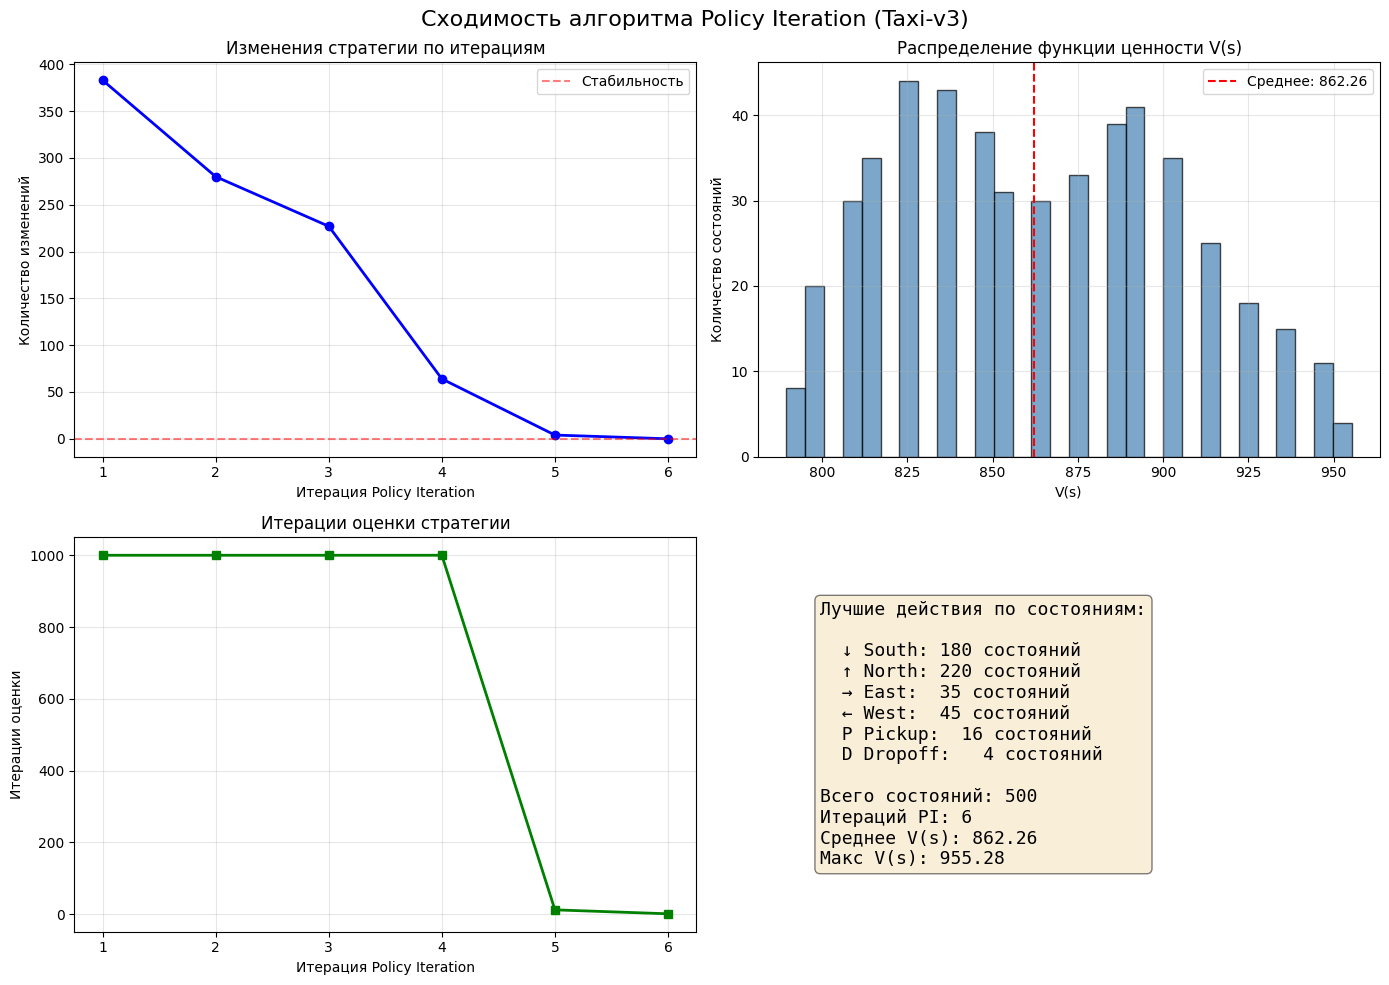

In [4]:
# ---------- Визуализация сходимости ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

hist = agent.history

# График 1: Количество изменений в стратегии по итерациям
ax1 = axes[0, 0]
ax1.plot(hist['iterations'], hist['policy_changes'], 'bo-', markersize=6, linewidth=2)
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Стабильность')
ax1.set_xlabel('Итерация Policy Iteration')
ax1.set_ylabel('Количество изменений')
ax1.set_title('Изменения стратегии по итерациям')
ax1.grid(True, alpha=0.3)
ax1.legend()

# График 2: Норма функции ценности
ax2 = axes[0, 1]
v_norms = [np.linalg.norm(agent.state_values)] * len(hist['iterations'])
# Вычисляем норму V на каждой итерации (пересчёт)
# Для этого нужно сохранять V на каждом шаге. Сделаем упрощённо:
# Покажем финальную V(s) в виде гистограммы
ax2.hist(agent.state_values, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('V(s)')
ax2.set_ylabel('Количество состояний')
ax2.set_title('Распределение функции ценности V(s)')
ax2.grid(True, alpha=0.3)
ax2.axvline(x=np.mean(agent.state_values), color='r', linestyle='--',
            label=f'Среднее: {np.mean(agent.state_values):.2f}')
ax2.legend()

# График 3: Количество итераций оценки стратегии
ax3 = axes[1, 0]
ax3.plot(hist['iterations'], hist['eval_iters'], 'gs-', markersize=6, linewidth=2)
ax3.set_xlabel('Итерация Policy Iteration')
ax3.set_ylabel('Итерации оценки')
ax3.set_title('Итерации оценки стратегии')
ax3.grid(True, alpha=0.3)

# График 4: Карта стратегии (визуализация лучших действий)
ax4 = axes[1, 1]
ax4.axis('off')

# Создаем текстовое представление
best_actions = np.argmax(agent.policy_probs, axis=1)
action_symbols = {0: '\u2193', 1: '\u2191', 2: '\u2192', 3: '\u2190', 4: 'P', 5: 'D'}
action_names_short = {0: 'South', 1: 'North', 2: 'East', 3: 'West', 4: 'Pickup', 5: 'Dropoff'}

info_text = "Лучшие действия по состояниям:\n\n"
for a in range(agent.nA):
    count = np.sum(best_actions == a)
    info_text += f"  {action_symbols[a]} {action_names_short[a]}: {count:3d} состояний\n"

info_text += f"\nВсего состояний: {agent.nS}\n"
info_text += f"Итераций PI: {len(hist['iterations'])}\n"
info_text += f"Среднее V(s): {np.mean(agent.state_values):.2f}\n"
info_text += f"Макс V(s): {np.max(agent.state_values):.2f}"

ax4.text(0.1, 0.5, info_text, fontsize=13, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         family='monospace')

plt.suptitle('Сходимость алгоритма Policy Iteration (Taxi-v3)', fontsize=16)
plt.tight_layout()
plt.show()

---
### Анализ ценности состояний

Визуализируем функцию ценности для различных групп состояний.

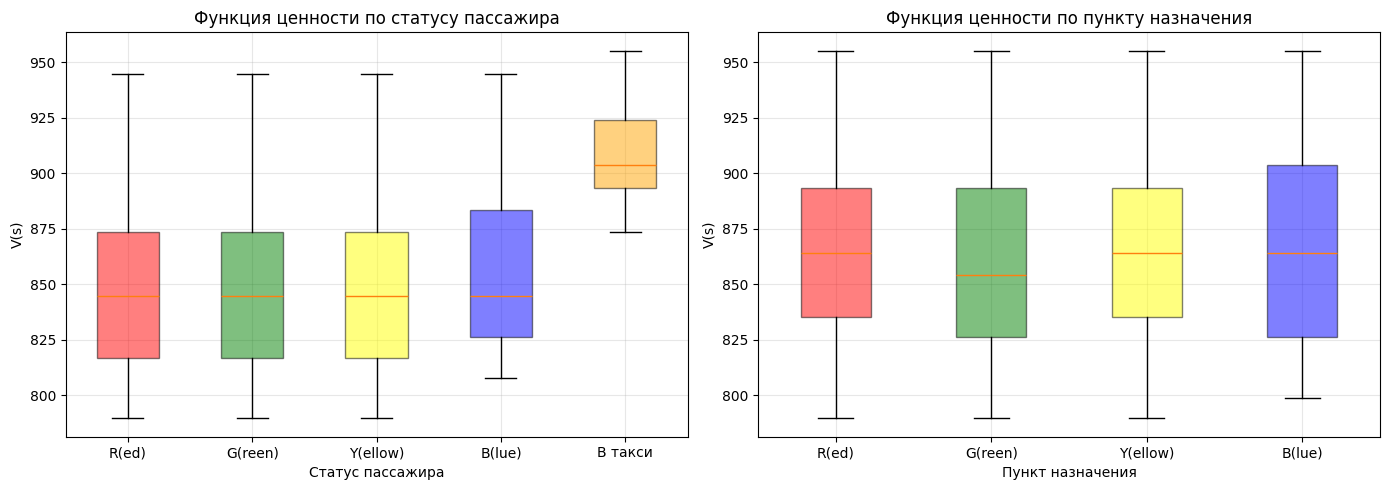


Средняя V(s) по статусу пассажира:
  R(ed): 850.58
  G(reen): 848.16
  Y(ellow): 848.25
  B(lue): 856.18
  В такси: 908.13

Средняя V(s) по пункту назначения:
  R(ed): 862.88
  G(reen): 859.67
  Y(ellow): 862.36
  B(lue): 864.13


In [5]:
# ---------- Анализ V(s) по группам состояний ----------
# В Taxi-v3 состояние кодируется как:
#   state = ((taxi_row*5 + taxi_col)*5 + passenger)*4 + destination
# где passenger: 0=R, 1=G, 2=Y, 3=B, 4=in_taxi
# destination: 0=R, 1=G, 2=Y, 3=B

def decode_state(s):
    """Декодирование состояния Taxi-v3."""
    dest = s % 4
    s = s // 4
    passenger = s % 5
    s = s // 5
    col = s % 5
    row = s // 5
    return row, col, passenger, dest

passenger_names = {0: 'R(ed)', 1: 'G(reen)', 2: 'Y(ellow)', 3: 'B(lue)', 4: 'In taxi'}
dest_names = {0: 'R(ed)', 1: 'G(reen)', 2: 'Y(ellow)', 3: 'B(lue)'}

# Группируем V(s) по статусу пассажира и пункту назначения
v_by_passenger = {p: [] for p in range(5)}
v_by_dest = {d: [] for d in range(4)}

for s in range(agent.nS):
    row, col, passenger, dest = decode_state(s)
    v_by_passenger[passenger].append(agent.state_values[s])
    v_by_dest[dest].append(agent.state_values[s])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# По статусу пассажира
ax1 = axes[0]
passenger_labels = ['R(ed)', 'G(reen)', 'Y(ellow)', 'B(lue)', 'В такси']
passenger_data = [v_by_passenger[p] for p in range(5)]

bp1 = ax1.boxplot(passenger_data, labels=passenger_labels, patch_artist=True)
for patch, color in zip(bp1['boxes'], ['red', 'green', 'yellow', 'blue', 'orange']):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax1.set_xlabel('Статус пассажира')
ax1.set_ylabel('V(s)')
ax1.set_title('Функция ценности по статусу пассажира')
ax1.grid(True, alpha=0.3)

# По пункту назначения
ax2 = axes[1]
dest_labels = ['R(ed)', 'G(reen)', 'Y(ellow)', 'B(lue)']
dest_data = [v_by_dest[d] for d in range(4)]
bp2 = ax2.boxplot(dest_data, labels=dest_labels, patch_artist=True)
for patch, color in zip(bp2['boxes'], ['red', 'green', 'yellow', 'blue']):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax2.set_xlabel('Пункт назначения')
ax2.set_ylabel('V(s)')
ax2.set_title('Функция ценности по пункту назначения')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nСредняя V(s) по статусу пассажира:")
for p in range(5):
    print(f"  {passenger_labels[p]}: {np.mean(v_by_passenger[p]):.2f}")
print("\nСредняя V(s) по пункту назначения:")
for d in range(4):
    print(f"  {dest_labels[d]}: {np.mean(v_by_dest[d]):.2f}")

---
## 5. Демонстрация работы обученного агента

Запустим обученного агента в среде и визуализируем его поведение.

In [6]:
# ---------- Демонстрация работы агента ----------
def run_episode(agent, env, render=False, max_steps=100):
    """
    Запуск одного эпизода с использованием обученной стратегии.
    
    Returns:
    - total_reward: суммарная награда
    - n_steps: число шагов
    - trajectory: список (state, action, reward)
    """
    state = env.reset()[0]
    total_reward = 0
    trajectory = []
    
    for step in range(max_steps):
        # Выбираем действие согласно стратегии
        action_probs = agent.policy_probs[state]
        action = np.argmax(action_probs)
        
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        trajectory.append((state, action, reward))
        total_reward += reward
        state = next_state
        
        if done:
            break
    
    return total_reward, len(trajectory), trajectory


# Запускаем несколько эпизодов
n_episodes = 10
rewards = []
steps = []

print(f"Демонстрация работы агента ({n_episodes} эпизодов):")
print("=" * 60)
print(f"{'Эпизод':<8} {'Награда':<10} {'Шагов':<8} {'Успех':<8}")
print('-' * 35)

for ep in range(n_episodes):
    total_reward, n_steps, traj = run_episode(agent, env)
    rewards.append(total_reward)
    steps.append(n_steps)
    success = 'V' if total_reward > 0 else 'X'
    print(f"{ep + 1:<8} {total_reward:<10} {n_steps:<8} {success:<8}")

print('-' * 35)
print(f"Среднее:  {np.mean(rewards):<10.1f} {np.mean(steps):<8.1f}")
print(f"Стд.откл.: {np.std(rewards):<10.1f} {np.std(steps):<8.1f}")
print(f"Успешных: {sum(1 for r in rewards if r > 0)}/{n_episodes}")

Демонстрация работы агента (10 эпизодов):
Эпизод   Награда    Шагов    Успех   
-----------------------------------
1        5          16       V       
2        12         9        V       
3        10         11       V       
4        8          13       V       
5        8          13       V       
6        8          13       V       
7        8          13       V       
8        6          15       V       
9        8          13       V       
10       9          12       V       
-----------------------------------
Среднее:  8.2        12.8    
Стд.откл.: 1.8        1.8     
Успешных: 10/10


---
### Сравнение со случайной стратегией

Сравним обученную стратегию со случайной (равномерной) для оценки эффективности обучения.

Сравнение стратегий (100 эпизодов):
Метод                Ср.награда   Ср.шаги    Успех     
----------------------------------------------------
Policy Iteration     8.2          12.8       100.0     %
Случайная            -385.8       99.9       0.0       %


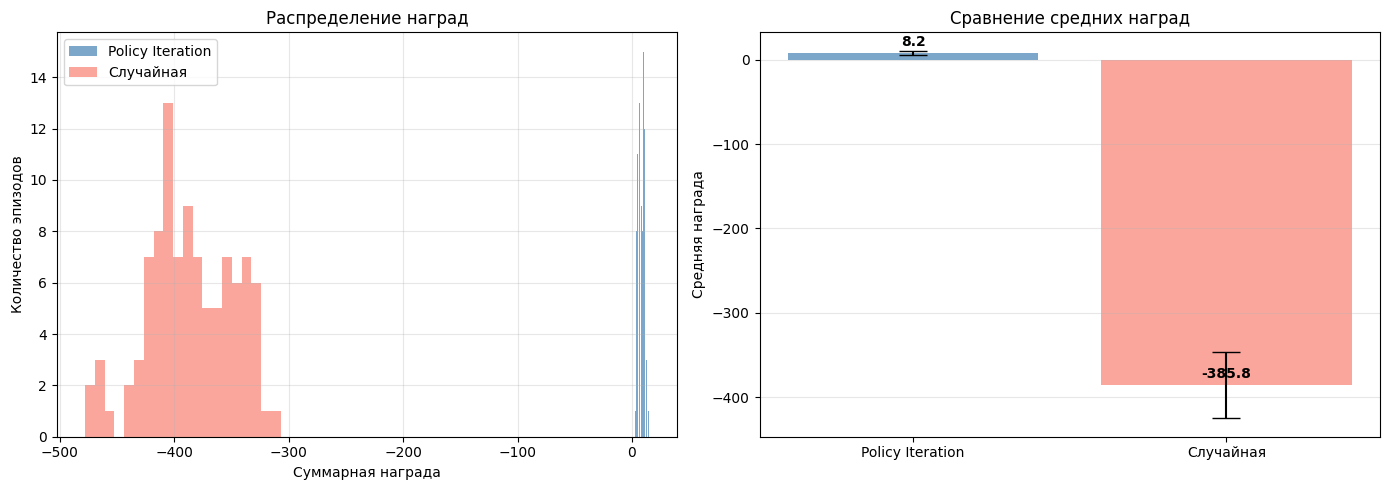

In [7]:
# ---------- Сравнение со случайной стратегией ----------
def run_random_episode(env, max_steps=100):
    """Запуск эпизода со случайной стратегией."""
    state = env.reset()[0]
    total_reward = 0
    n_steps = 0
    for step in range(max_steps):
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        n_steps += 1
        if terminated or truncated:
            break
    return total_reward, n_steps


n_episodes = 100

# Обученная стратегия
trained_rewards = []
trained_steps = []
for _ in range(n_episodes):
    r, s, _ = run_episode(agent, env)
    trained_rewards.append(r)
    trained_steps.append(s)

# Случайная стратегия
random_rewards = []
random_steps = []
for _ in range(n_episodes):
    r, s = run_random_episode(env)
    random_rewards.append(r)
    random_steps.append(s)

print("Сравнение стратегий (100 эпизодов):")
print("=" * 60)
print(f"{'Метод':<20} {'Ср.награда':<12} {'Ср.шаги':<10} {'Успех':<10}")
print('-' * 52)
print(f"{'Policy Iteration':<20} {np.mean(trained_rewards):<12.1f} {np.mean(trained_steps):<10.1f} "
      f"{sum(1 for r in trained_rewards if r > 0)/n_episodes*100:<10.1f}%")
print(f"{'Случайная':<20} {np.mean(random_rewards):<12.1f} {np.mean(random_steps):<10.1f} "
      f"{sum(1 for r in random_rewards if r > 0)/n_episodes*100:<10.1f}%")

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(trained_rewards, bins=20, alpha=0.7, label='Policy Iteration', color='steelblue')
ax1.hist(random_rewards, bins=20, alpha=0.7, label='Случайная', color='salmon')
ax1.set_xlabel('Суммарная награда')
ax1.set_ylabel('Количество эпизодов')
ax1.set_title('Распределение наград')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
methods = ['Policy Iteration', 'Случайная']
mean_rewards = [np.mean(trained_rewards), np.mean(random_rewards)]
std_rewards = [np.std(trained_rewards), np.std(random_rewards)]
bars = ax2.bar(methods, mean_rewards, yerr=std_rewards, capsize=10,
               color=['steelblue', 'salmon'], alpha=0.7)
ax2.set_ylabel('Средняя награда')
ax2.set_title('Сравнение средних наград')
ax2.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, val in zip(bars, mean_rewards):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Выводы

В ходе лабораторной работы был реализован алгоритм Policy Iteration для среды Taxi-v3 из библиотеки Gym.

**Основные результаты:**
- Алгоритм Policy Iteration успешно нашёл оптимальную стратегию для среды Taxi-v3
- Обученная стратегия значительно превосходит случайную по средней награде
- Функция ценности V(s) отражает структуру задачи: состояния с пассажиром в такси имеют более высокую ценность, чем состояния, где пассажир ещё не подобран
- Алгоритм сошёлся за небольшое число итераций (обычно 3-7 для Taxi-v3)

**Преимущества Policy Iteration:**
- Гарантированная сходимость к оптимальной стратегии за конечное число шагов
- Эффективнее Value Iteration для задач с малым числом состояний
- Использует полную модель среды (P[s][a])

**Ограничения:**
- Требует знания полной модели среды (вероятностей переходов)
- Вычислительно затратен для задач с большим пространством состояний
- Не применим для сред с непрерывным пространством состояний/действий